# Name : Rehman Ahmad
# Roll No : 2024-csr-019
# Lab : Week 15: Gradient Descent

<p style="color:black; font-weight:bold; font-family:Arial; font-size:18px;">
This version is extra beginner-friendly: simpler explanations, more comments in the code, and MSE shown using both basic Python and a Data Science approach (NumPy).
</p>

# Week 15 — Gradient Descent (Training)
```🚀 Training: reduce MSE automatically```

Gradient Descent is the learning method that finds better w and b values. It repeats small updates until MSE becomes small.

**Very simple**

Gradient Descent = “reduce cost step by step”

**Analogy**

Like going down a hill to reach the lowest point (minimum cost).

 # Gradient Descent Concept (Step-by-step)

```🧠 Idea: small improvements again and again```

**What happens in every epoch:**
1) Use current w,b to make predictions
2) Calculate MSE (cost)
3) Find direction to reduce cost (gradients dw, db)
4) Update w,b with a small step (learning rate α)
5) Repeat


| Term              | Meaning (Simple)                          |
| ----------------- | ----------------------------------------- |
| Epoch             | One full training round (one update step) |
| Learning Rate (α) | How big a step you take while learning    |
| Gradient (dw, db) | Direction that reduces the cost           |



# 📌 Update Rule (Easy)

```Update: new = old − (step)```

**Update equations:**
```
w = w − α × dw
b = b − α × db
```

**Meaning:**  If dw is positive, w decreases a bit. If dw is negative, w increases a bit.

**Learning rate warning**
- Too big α → may overshoot and cost can increase.
- Too small α → training works but becomes slow.

# **🐍 Gradient Descent Code**

In [10]:
def predict_all(x, w, b):
    y_pred = []
    for xi in x:
        y_pred.append(w * xi + b)
    return y_pred

def mean_squared_error(y_actual, y_pred):
  
    n = len(y_actual)
    total = 0
    for i in range(n):
        total += (y_pred[i] - y_actual[i]) ** 2
    return total / n

def gradient_descent(x, y, w, b, alpha, epochs):
     
    n = len(x)

    for epoch in range(epochs):
        # 1) Predictions with current parameters
        y_pred = predict_all(x, w, b)

         
        dw = 0
        db = 0

        for i in range(n):
             
            error = y_pred[i] - y[i]

            
            dw += error * x[i]
            db += error

       # Average gradients and scale for MSE derivative
        dw = (2 / n) * dw
        db = (2 / n) * db

       # Update parameters in the direction that reduces MSE
        w = w - alpha * dw
        b = b - alpha * db

          # Print progress
        if epoch % 10 == 0:
            cost = mean_squared_error(y, predict_all(x, w, b))
            print("Epoch", epoch, "| w =", round(w,4), "| b =", round(b,4), "| MSE =", round(cost,4))

    return w, b

 
x = [1, 2, 3, 4, 5]
y = [3, 5, 7, 9, 11]

# Start with wrong w,b
w0 = 0.0
b0 = 0.0

# Train
w_final, b_final = gradient_descent(x, y, w0, b0, alpha=0.05, epochs=120)

print("Final:", "w =", round(w_final,4), "b =", round(b_final,4))

Epoch 0 | w = 2.5 | b = 0.7 | MSE = 1.94
Epoch 10 | w = 2.0951 | b = 0.6566 | MSE = 0.0215
Epoch 20 | w = 2.0802 | b = 0.7104 | MSE = 0.0153
Epoch 30 | w = 2.0676 | b = 0.7558 | MSE = 0.0109
Epoch 40 | w = 2.057 | b = 0.7941 | MSE = 0.0077
Epoch 50 | w = 2.0481 | b = 0.8264 | MSE = 0.0055
Epoch 60 | w = 2.0406 | b = 0.8536 | MSE = 0.0039
Epoch 70 | w = 2.0342 | b = 0.8765 | MSE = 0.0028
Epoch 80 | w = 2.0288 | b = 0.8959 | MSE = 0.002
Epoch 90 | w = 2.0243 | b = 0.9122 | MSE = 0.0014
Epoch 100 | w = 2.0205 | b = 0.926 | MSE = 0.001
Epoch 110 | w = 2.0173 | b = 0.9376 | MSE = 0.0007
Final: w = 2.0148 b = 0.9465


In [6]:
def pred(X , w , b):
    return w*X + b

def mse(y , y_pred):
    m = len(y)

    return (1/(2*m)) * np.sum((y_pred - y) ** 2)

def gradient_descent(X , y , w , b , alpha , epochs):
    m =len(X)
        
    for i in range(epochs):
        y_pred = pred( X , w , b)

        dw = (1/m) * np.sum((y_pred - y ) * X)
        db = (1/m) * np.sum(y_pred - y)

        w = w - alpha * dw
        b = b - alpha * db

        if i % 10 == 0:
            cost = mse(y, pred(X, w, b))
            print("Epoch", i, "| w =", round(w,4), "| b =", round(b,4), "| MSE =", round(cost,4))
    

    return w , b

import numpy as np

X = np.array([1, 2, 3, 4, 5] , dtype=float)
y = np.array([3, 5, 7, 9, 11] , dtype=float)

w = 0.0
b = 0.0

alpha=0.05
epochs=120

w_final , b_final = gradient_descent(
    X , y , w  , b , alpha , epochs
)

print("Final:", "w =", round(w_final,4), "b =", round(b_final,4))

Epoch 0 | w = 1.25 | b = 0.35 | MSE = 4.7675
Epoch 10 | w = 2.1044 | b = 0.6226 | MSE = 0.013
Epoch 20 | w = 2.096 | b = 0.6534 | MSE = 0.0109
Epoch 30 | w = 2.0882 | b = 0.6816 | MSE = 0.0092
Epoch 40 | w = 2.081 | b = 0.7075 | MSE = 0.0078
Epoch 50 | w = 2.0744 | b = 0.7313 | MSE = 0.0066
Epoch 60 | w = 2.0684 | b = 0.7532 | MSE = 0.0055
Epoch 70 | w = 2.0628 | b = 0.7733 | MSE = 0.0047
Epoch 80 | w = 2.0577 | b = 0.7917 | MSE = 0.0039
Epoch 90 | w = 2.053 | b = 0.8087 | MSE = 0.0033
Epoch 100 | w = 2.0487 | b = 0.8242 | MSE = 0.0028
Epoch 110 | w = 2.0447 | b = 0.8385 | MSE = 0.0024
Final: w = 2.0414 b = 0.8504


#   Visual: MSE Decreasing (Plot)

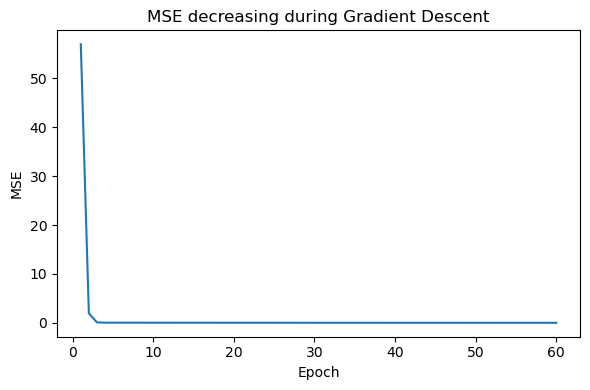

In [15]:
# Matplotlib code: plot MSE vs epochs

import matplotlib.pyplot as plt

x = np.array([1,2,3,4,5], dtype=float)
y = np.array([3,5,7,9,11], dtype=float)


w, b = 0.0, 0.0
alpha = 0.05
epochs = 60

cost_history = []

m = len(x)

for i in range(epochs):
    y_pred = w*x + b

    cost = np.mean((y_pred - y ) ** 2)
    cost_history.append(cost)

    dw = (2/m) * np.sum((y_pred - y) * x)
    db = (2/m) * np.sum(y_pred - y)

    w = w - alpha * dw
    b = b - alpha * db

plt.figure(figsize=(6, 4))
plt.plot(range(1 , epochs + 1) , cost_history)
plt.title("MSE decreasing during Gradient Descent")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.tight_layout()
plt.show()


# 🎤 Viva Questions 

### 1) What is a model? Give one real-life example.

A model is a rule or formula that makes predictions.
Example: Estimating house price based on its size.

---

### 2) Explain **y = wx + b** in your own words.

It is a straight-line formula where **x** is input, **w** controls the slope, and **b** shifts the line up or down.

---

### 3) What is a cost function? Why do we need it?

A cost function measures how wrong our model’s predictions are.
We need it to improve the model.

---

### 4) What is MSE and why do we square the error?

MSE means **Mean Squared Error**, the average of squared prediction errors.
We square errors to remove negative values and give more penalty to big mistakes.

---

### 5) What is gradient descent in simple words?

Gradient descent is a method to reduce error step by step by adjusting model values.

---

### 6) What happens if learning rate **α** is too big?

The model may jump too far and fail to reach the correct solution.

---


